# Walkthroughs and Exercises for GenAI-Powered Data Analysis in Python

Dr. Chester Ismay

# Data Analytics Kickoff + Course Goals

## Walkthrough #1: Setting Up the Python Environment

If you haven’t already installed Python, Jupyter, and the necessary
packages, there are instructions on the course repo in the README to do
so
[here](https://github.com/ismayc/oreilly-genai-powered-data-analysis-with-python/blob/main/README.md).

If you aren’t able to do this on your machine, you may want to check out
[Google Colab](https://colab.research.google.com/). It’s a free service
that allows you to run Jupyter notebooks in the cloud.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# For plotly to load directly in Jupyter notebook
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

## Exercise #1: Setting Up the Python Environment

Follow the instructions above in Walkthrough #1 to check for correct
installation of necessary packages. We’ll wait a few minutes to make
sure as many of you are set up as possible. Please give a thumbs up in
the pulse check if you are ready to move on.

We’ll work with ChatGPT as our GenAI tool. If you are getting errors at
this point and would like to ask it for assistance, go for it! We’ll
make more use of it throughout the course, and I’ll give tips along the
way too.

------------------------------------------------------------------------

# *Day 1: Prompt to Wrangle*

------------------------------------------------------------------------

# Module 1: Data Wrangling with Pandas

## Walkthrough #2: Cleaning and Preparing Data with Pandas

### Import data from a CSV or from an Excel file

In [3]:
# Load the data from a CSV file
economies = pd.read_csv("economies.csv")

### Perform an initial exploration of the data

In [4]:
# Display the first few rows of the DataFrame
economies.head()

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group
0,ABW,Aruba,2010,24087.950,13.255,2.078,NaN,10.600,NaN,NaN,High income
1,ABW,Aruba,2015,27126.620,21.411,0.475,NaN,7.298,NaN,NaN,High income
2,ABW,Aruba,2020,21832.920,-7.521,-1.338,NaN,13.997,NaN,NaN,High income
3,AFG,Afghanistan,2010,631.490,59.699,2.179,30.269,NaN,9.768,32.285,Low income
4,AFG,Afghanistan,2015,711.337,22.223,-0.662,18.427,NaN,-11.585,15.309,Low income


In [5]:
# Display the information about the DataFrame
economies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code               561 non-null    object 
 1   country            561 non-null    object 
 2   year               561 non-null    int64  
 3   gdp_percapita      558 non-null    float64
 4   gross_savings      490 non-null    float64
 5   inflation_rate     555 non-null    float64
 6   total_investment   490 non-null    float64
 7   unemployment_rate  312 non-null    float64
 8   exports            509 non-null    float64
 9   imports            506 non-null    float64
 10  income_group       561 non-null    object 
dtypes: float64(7), int64(1), object(3)
memory usage: 48.3+ KB


In [6]:
# Display summary statistics of the DataFrame
economies.describe()

,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports
count,561.000000,558.000000,490.000000,555.000000,490.000000,312.000000,509.000000,506.000000
mean,2015.000000,13447.838281,20.641665,9.762438,25.348976,8.894619,-0.844275,0.813121
std,4.086126,18481.107981,10.813159,103.013164,23.546022,5.605188,17.817279,15.644724
min,2010.000000,231.549000,-10.331000,-3.900000,0.521000,0.900000,-80.939000,-59.381000
25%,2010.000000,1842.815000,14.129000,0.731000,18.449250,5.252250,-8.528000,-8.253000
50%,2015.000000,5049.830000,20.536000,2.507000,22.808000,7.400000,1.000000,1.334000
75%,2020.000000,16509.697500,26.819750,5.406000,27.644750,10.772000,8.033000,9.348000
max,2020.000000,116921.110000,59.699000,2355.150000,363.411000,32.050000,159.103000,84.555000


### Handle missing data

#### Remove rows

In [7]:
# Remove rows with any missing values
economies_cleaned_any = economies.dropna(how='any')
economies_cleaned_any

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group
9,ALB,Albania,2010,4097.83,20.023,3.615,31.318,14.000,10.473,-9.316,Upper middle income
10,ALB,Albania,2015,3953.61,15.804,1.868,26.237,17.100,5.272,0.076,Upper middle income
11,ALB,Albania,2020,5286.68,13.255,1.603,22.845,12.500,-28.951,-21.446,Upper middle income
15,ARG,Argentina,2010,10412.97,17.323,10.461,17.706,7.750,13.701,39.414,Upper middle income
17,ARG,Argentina,2020,8554.64,17.798,42.015,16.845,11.364,-13.124,-10.722,Upper middle income
...,...,...,...,...,...,...,...,...,...,...,...
541,VNM,Vietnam,2015,2582.39,26.444,0.631,27.339,2.330,9.713,15.426,Lower middle income
542,VNM,Vietnam,2020,3498.98,28.603,3.222,26.444,3.300,2.822,2.948,Lower middle income
552,ZAF,South Africa,2010,7311.74,18.012,4.264,19.513,24.875,7.718,10.794,Upper middle income
553,ZAF,South Africa,2015,5731.73,16.300,4.575,20.918,25.350,2.925,5.443,Upper middle income


In [8]:
# Remove rows with missing values in specific columns
economies_cleaned_subset = economies.dropna(subset=['exports', 'imports'])
economies_cleaned_subset

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group
3,AFG,Afghanistan,2010,631.490,59.699,2.179,30.269,NaN,9.768,32.285,Low income
4,AFG,Afghanistan,2015,711.337,22.223,-0.662,18.427,NaN,-11.585,15.309,Low income
5,AFG,Afghanistan,2020,580.817,27.132,5.607,16.420,NaN,-10.424,2.892,Low income
6,AGO,Angola,2010,3641.440,34.833,14.480,28.197,NaN,-3.266,-21.656,Lower middle income
7,AGO,Angola,2015,4354.920,28.491,9.159,34.202,NaN,6.721,-19.515,Lower middle income
...,...,...,...,...,...,...,...,...,...,...,...
553,ZAF,South Africa,2015,5731.730,16.300,4.575,20.918,25.350,2.925,5.443,Upper middle income
554,ZAF,South Africa,2020,5067.150,14.602,3.268,12.426,29.175,-10.280,-16.615,Upper middle income
555,ZMB,Zambia,2010,1456.050,37.405,8.500,29.878,NaN,19.476,32.492,Lower middle income
556,ZMB,Zambia,2015,1310.460,40.103,10.107,42.791,NaN,-11.407,0.696,Lower middle income


#### Replace missing values with specific value

In [9]:
# Replace missing values with a specific value (e.g., 0 for numerical columns, 'Unknown' for categorical columns)
economies_fill_value = economies.fillna({
    'gdp_percapita': 0,
    'gross_savings': 0,
    'inflation_rate': 0,
    'total_investment': 0,
    'unemployment_rate': 0,
    'exports': 0,
    'imports': 0,
    'income_group': 'Unknown'
})

# Display the DataFrame after replacing missing values with specific values
economies_fill_value.head()

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group
0,ABW,Aruba,2010,24087.950,13.255,2.078,0.000,10.600,0.000,0.000,High income
1,ABW,Aruba,2015,27126.620,21.411,0.475,0.000,7.298,0.000,0.000,High income
2,ABW,Aruba,2020,21832.920,-7.521,-1.338,0.000,13.997,0.000,0.000,High income
3,AFG,Afghanistan,2010,631.490,59.699,2.179,30.269,0.000,9.768,32.285,Low income
4,AFG,Afghanistan,2015,711.337,22.223,-0.662,18.427,0.000,-11.585,15.309,Low income


This can be extended to replace missing values with the mean, median, or
mode of the column too.

### Convert a column to a different data type

In [10]:
# Change year to be a string instead of an integer
economies_char_year = economies.astype({'year': 'str'})

# Display the information on the DataFrame with year as a string
economies_char_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code               561 non-null    object 
 1   country            561 non-null    object 
 2   year               561 non-null    object 
 3   gdp_percapita      558 non-null    float64
 4   gross_savings      490 non-null    float64
 5   inflation_rate     555 non-null    float64
 6   total_investment   490 non-null    float64
 7   unemployment_rate  312 non-null    float64
 8   exports            509 non-null    float64
 9   imports            506 non-null    float64
 10  income_group       561 non-null    object 
dtypes: float64(7), object(4)
memory usage: 48.3+ KB


In [11]:
# Change the year of string type back to integer
economies_int_year = economies_char_year.astype({'year': 'int'})

# Display the information on the DataFrame with year as an integer
economies_int_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code               561 non-null    object 
 1   country            561 non-null    object 
 2   year               561 non-null    int64  
 3   gdp_percapita      558 non-null    float64
 4   gross_savings      490 non-null    float64
 5   inflation_rate     555 non-null    float64
 6   total_investment   490 non-null    float64
 7   unemployment_rate  312 non-null    float64
 8   exports            509 non-null    float64
 9   imports            506 non-null    float64
 10  income_group       561 non-null    object 
dtypes: float64(7), int64(1), object(3)
memory usage: 48.3+ KB


### Rename a column

In [12]:
# Rename the 'income_group' column to 'income_category'
economies_renamed = economies.rename(columns={'income_group': 'income_category'})
economies_renamed.head()

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_category
0,ABW,Aruba,2010,24087.950,13.255,2.078,NaN,10.600,NaN,NaN,High income
1,ABW,Aruba,2015,27126.620,21.411,0.475,NaN,7.298,NaN,NaN,High income
2,ABW,Aruba,2020,21832.920,-7.521,-1.338,NaN,13.997,NaN,NaN,High income
3,AFG,Afghanistan,2010,631.490,59.699,2.179,30.269,NaN,9.768,32.285,Low income
4,AFG,Afghanistan,2015,711.337,22.223,-0.662,18.427,NaN,-11.585,15.309,Low income


### Filtering rows based on conditions

#### Conditions on a single column

In [13]:
# Filter rows where 'gdp_percapita' is greater than 20,000
economies[economies['gdp_percapita'] > 20000]

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group
0,ABW,Aruba,2010,24087.95,13.255,2.078,NaN,10.600,NaN,NaN,High income
1,ABW,Aruba,2015,27126.62,21.411,0.475,NaN,7.298,NaN,NaN,High income
2,ABW,Aruba,2020,21832.92,-7.521,-1.338,NaN,13.997,NaN,NaN,High income
12,ARE,United Arab Emirates,2010,35064.26,31.330,0.878,27.121,NaN,7.540,0.405,High income
13,ARE,United Arab Emirates,2015,37380.57,30.540,4.070,25.639,NaN,3.055,2.488,High income
...,...,...,...,...,...,...,...,...,...,...,...
475,SWE,Sweden,2015,51274.28,27.743,0.704,24.429,7.400,4.995,5.031,High income
476,SWE,Sweden,2020,51796.38,29.755,0.657,24.518,8.292,-5.191,-5.358,High income
528,USA,United States,2010,48403.30,15.466,1.637,18.743,9.608,12.137,13.128,High income
529,USA,United States,2015,56848.51,20.141,0.121,21.163,5.275,0.421,5.175,High income


In [14]:
# Filter rows where 'income_group' is 'High income'
economies[economies['income_group'] == 'High income']

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group
0,ABW,Aruba,2010,24087.95,13.255,2.078,NaN,10.600,NaN,NaN,High income
1,ABW,Aruba,2015,27126.62,21.411,0.475,NaN,7.298,NaN,NaN,High income
2,ABW,Aruba,2020,21832.92,-7.521,-1.338,NaN,13.997,NaN,NaN,High income
12,ARE,United Arab Emirates,2010,35064.26,31.330,0.878,27.121,NaN,7.540,0.405,High income
13,ARE,United Arab Emirates,2015,37380.57,30.540,4.070,25.639,NaN,3.055,2.488,High income
...,...,...,...,...,...,...,...,...,...,...,...
526,URY,Uruguay,2015,16692.65,17.223,8.666,17.477,7.525,-7.564,-8.145,High income
527,URY,Uruguay,2020,15777.96,12.873,9.756,14.319,10.350,-28.231,-12.544,High income
528,USA,United States,2010,48403.30,15.466,1.637,18.743,9.608,12.137,13.128,High income
529,USA,United States,2015,56848.51,20.141,0.121,21.163,5.275,0.421,5.175,High income


#### Conditions on multiple columns

In [15]:
# Filter rows where inflation_rate is less than 0 and income_group is 'Low income'
economies[(economies['inflation_rate'] < 0) & (economies['income_group'] == 'Low income')]

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group
4,AFG,Afghanistan,2015,711.337,22.223,-0.662,18.427,NaN,-11.585,15.309,Low income
42,BFA,Burkina Faso,2010,648.365,20.194,-0.608,21.990,NaN,54.547,13.986,Low income
486,TCD,Chad,2010,895.354,25.871,-2.110,34.388,NaN,-5.488,17.218,Low income


## Exercise #2: Cleaning and Preparing Data with Pandas

In [16]:
# Load the populations data from a CSV file
populations = pd.read_csv("populations.csv")

# Examine the first few rows
populations.head()

# Display the information about the DataFrame
populations.info()

# Display summary statistics of the DataFrame
populations.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country_code         645 non-null    object 
 1   country              645 non-null    object 
 2   year                 645 non-null    int64  
 3   fertility_rate       627 non-null    float64
 4   life_expectancy      623 non-null    float64
 5   size                 645 non-null    int64  
 6   official_state_name  645 non-null    object 
 7   sovereignty          645 non-null    object 
 8   continent            645 non-null    object 
 9   region               645 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 50.5+ KB


,year,fertility_rate,life_expectancy,size
count,645.000000,627.000000,623.000000,6.450000e+02
mean,2015.000000,2.727907,71.553996,3.429149e+07
std,4.085651,1.386750,8.118422,1.346457e+08
min,2010.000000,0.837000,45.596000,1.024100e+04
25%,2010.000000,1.670000,65.742000,7.550310e+05
50%,2015.000000,2.216000,73.004000,6.292731e+06
75%,2020.000000,3.537500,77.720695,2.301265e+07
max,2020.000000,7.485000,85.497561,1.411100e+09


### Handle Missing Data

#### Remove rows

In [17]:
# Remove rows with any missing values
populations.dropna(how='any')

,country_code,country,year,fertility_rate,life_expectancy,size,official_state_name,sovereignty,continent,region
0,ABW,Aruba,2010,1.941,75.404,100341,Aruba,Netherlands,North America,Caribbean
1,ABW,Aruba,2015,1.972,75.683,104257,Aruba,Netherlands,North America,Caribbean
2,ABW,Aruba,2020,1.325,75.723,106585,Aruba,Netherlands,North America,Caribbean
3,AFG,Afghanistan,2010,6.099,60.851,28189672,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
4,AFG,Afghanistan,2015,5.405,62.659,33753499,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
...,...,...,...,...,...,...,...,...,...,...
640,ZMB,Zambia,2015,4.793,61.208,16248230,The Republic of Zambia,UN member,Africa,Eastern Africa
641,ZMB,Zambia,2020,4.379,62.380,18927715,The Republic of Zambia,UN member,Africa,Eastern Africa
642,ZWE,Zimbabwe,2010,4.025,50.652,12839771,The Republic of Zimbabwe,UN member,Africa,Eastern Africa
643,ZWE,Zimbabwe,2015,3.849,59.591,14154937,The Republic of Zimbabwe,UN member,Africa,Eastern Africa


In [18]:
# Remove rows with missing values in specific columns
populations.dropna(subset=['fertility_rate', 'life_expectancy'])

,country_code,country,year,fertility_rate,life_expectancy,size,official_state_name,sovereignty,continent,region
0,ABW,Aruba,2010,1.941,75.404,100341,Aruba,Netherlands,North America,Caribbean
1,ABW,Aruba,2015,1.972,75.683,104257,Aruba,Netherlands,North America,Caribbean
2,ABW,Aruba,2020,1.325,75.723,106585,Aruba,Netherlands,North America,Caribbean
3,AFG,Afghanistan,2010,6.099,60.851,28189672,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
4,AFG,Afghanistan,2015,5.405,62.659,33753499,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
...,...,...,...,...,...,...,...,...,...,...
640,ZMB,Zambia,2015,4.793,61.208,16248230,The Republic of Zambia,UN member,Africa,Eastern Africa
641,ZMB,Zambia,2020,4.379,62.380,18927715,The Republic of Zambia,UN member,Africa,Eastern Africa
642,ZWE,Zimbabwe,2010,4.025,50.652,12839771,The Republic of Zimbabwe,UN member,Africa,Eastern Africa
643,ZWE,Zimbabwe,2015,3.849,59.591,14154937,The Republic of Zimbabwe,UN member,Africa,Eastern Africa


#### Replace missing values with specific value

In [19]:
# Replace missing values with a specific value (e.g., 0 for numerical columns, 
# 'Unknown' for categorical columns)
populations_fill_value = populations.fillna({
    'fertility_rate': 0,
    'life_expectancy': 0,
    'size': 0,
    'continent': 'Unknown',
    'region': 'Unknown'
})
populations_fill_value

,country_code,country,year,fertility_rate,life_expectancy,size,official_state_name,sovereignty,continent,region
0,ABW,Aruba,2010,1.941,75.404,100341,Aruba,Netherlands,North America,Caribbean
1,ABW,Aruba,2015,1.972,75.683,104257,Aruba,Netherlands,North America,Caribbean
2,ABW,Aruba,2020,1.325,75.723,106585,Aruba,Netherlands,North America,Caribbean
3,AFG,Afghanistan,2010,6.099,60.851,28189672,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
4,AFG,Afghanistan,2015,5.405,62.659,33753499,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
...,...,...,...,...,...,...,...,...,...,...
640,ZMB,Zambia,2015,4.793,61.208,16248230,The Republic of Zambia,UN member,Africa,Eastern Africa
641,ZMB,Zambia,2020,4.379,62.380,18927715,The Republic of Zambia,UN member,Africa,Eastern Africa
642,ZWE,Zimbabwe,2010,4.025,50.652,12839771,The Republic of Zimbabwe,UN member,Africa,Eastern Africa
643,ZWE,Zimbabwe,2015,3.849,59.591,14154937,The Republic of Zimbabwe,UN member,Africa,Eastern Africa


### Convert a Column to a Different Data Type and Rename a Column

#### Convert a Column to a Different Data Type

In [20]:
# Convert the 'year' column to string type
populations['year'] = populations['year'].astype(str)
populations.dtypes

country_code            object
country                 object
year                    object
fertility_rate         float64
life_expectancy        float64
size                     int64
official_state_name     object
sovereignty             object
continent               object
region                  object
dtype: object

In [21]:
# Convert it back to integer
populations['year'] = populations['year'].astype(int)
populations.dtypes

country_code            object
country                 object
year                     int64
fertility_rate         float64
life_expectancy        float64
size                     int64
official_state_name     object
sovereignty             object
continent               object
region                  object
dtype: object

#### Rename a Column

In [22]:
# Rename the 'fertility_rate' column to 'fertility'
populations_renamed = populations.rename(columns={'fertility_rate': 'fertility'})
populations_renamed

,country_code,country,year,fertility,life_expectancy,size,official_state_name,sovereignty,continent,region
0,ABW,Aruba,2010,1.941,75.404,100341,Aruba,Netherlands,North America,Caribbean
1,ABW,Aruba,2015,1.972,75.683,104257,Aruba,Netherlands,North America,Caribbean
2,ABW,Aruba,2020,1.325,75.723,106585,Aruba,Netherlands,North America,Caribbean
3,AFG,Afghanistan,2010,6.099,60.851,28189672,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
4,AFG,Afghanistan,2015,5.405,62.659,33753499,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
...,...,...,...,...,...,...,...,...,...,...
640,ZMB,Zambia,2015,4.793,61.208,16248230,The Republic of Zambia,UN member,Africa,Eastern Africa
641,ZMB,Zambia,2020,4.379,62.380,18927715,The Republic of Zambia,UN member,Africa,Eastern Africa
642,ZWE,Zimbabwe,2010,4.025,50.652,12839771,The Republic of Zimbabwe,UN member,Africa,Eastern Africa
643,ZWE,Zimbabwe,2015,3.849,59.591,14154937,The Republic of Zimbabwe,UN member,Africa,Eastern Africa


#### Filter a DataFrame

In [23]:
# Filter the DataFrame to include only rows where the 'continent' is 'Asia'
populations[populations['continent'] == 'Asia']

,country_code,country,year,fertility_rate,life_expectancy,size,official_state_name,sovereignty,continent,region
3,AFG,Afghanistan,2010,6.099,60.851,28189672,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
4,AFG,Afghanistan,2015,5.405,62.659,33753499,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
5,AFG,Afghanistan,2020,4.750,62.575,38972230,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
15,ARE,United Arab Emirates,2010,1.790,78.334,8481771,The United Arab Emirates,UN member,Asia,Middle East
16,ARE,United Arab Emirates,2015,1.486,79.223,8916899,The United Arab Emirates,UN member,Asia,Middle East
...,...,...,...,...,...,...,...,...,...,...
625,VNM,Vietnam,2015,1.951,73.876,92191398,The Socialist Republic of Vietnam,UN member,Asia,Southeast Asia
626,VNM,Vietnam,2020,1.955,75.378,96648685,The Socialist Republic of Vietnam,UN member,Asia,Southeast Asia
633,YEM,Yemen,2010,4.855,67.280,24743946,The Republic of Yemen,UN member,Asia,Middle East
634,YEM,Yemen,2015,4.322,65.873,28516545,The Republic of Yemen,UN member,Asia,Middle East


In [24]:
# Filter the DataFrame to include only rows where the 'year' is 2020
populations[populations['year'] == 2020]

,country_code,country,year,fertility_rate,life_expectancy,size,official_state_name,sovereignty,continent,region
2,ABW,Aruba,2020,1.325,75.723,106585,Aruba,Netherlands,North America,Caribbean
5,AFG,Afghanistan,2020,4.750,62.575,38972230,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
8,AGO,Angola,2020,5.371,62.261,33428486,The Republic of Angola,UN member,Africa,Central Africa
11,ALB,Albania,2020,1.400,76.989,2837849,The Republic of Albania,UN member,Europe,Southern Europe
14,AND,Andorra,2020,NaN,NaN,77700,The Principality of Andorra,UN member,Europe,Southern Europe
...,...,...,...,...,...,...,...,...,...,...
632,WSM,Samoa,2020,3.997,72.768,214929,The Independent State of Samoa,UN member,Oceania,Polynesia
635,YEM,Yemen,2020,3.886,64.650,32284046,The Republic of Yemen,UN member,Asia,Middle East
638,ZAF,South Africa,2020,2.401,65.252,58801927,The Republic of South Africa,UN member,Africa,Southern Africa
641,ZMB,Zambia,2020,4.379,62.380,18927715,The Republic of Zambia,UN member,Africa,Eastern Africa


In [25]:
# Filter the DataFrame to include only rows where the 'fertility_rate' is greater than 2
populations[populations['fertility_rate'] > 2]

,country_code,country,year,fertility_rate,life_expectancy,size,official_state_name,sovereignty,continent,region
3,AFG,Afghanistan,2010,6.099,60.851,28189672,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
4,AFG,Afghanistan,2015,5.405,62.659,33753499,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
5,AFG,Afghanistan,2020,4.750,62.575,38972230,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia
6,AGO,Angola,2010,6.194,56.726,23364185,The Republic of Angola,UN member,Africa,Central Africa
7,AGO,Angola,2015,5.774,60.655,28127721,The Republic of Angola,UN member,Africa,Central Africa
...,...,...,...,...,...,...,...,...,...,...
640,ZMB,Zambia,2015,4.793,61.208,16248230,The Republic of Zambia,UN member,Africa,Eastern Africa
641,ZMB,Zambia,2020,4.379,62.380,18927715,The Republic of Zambia,UN member,Africa,Eastern Africa
642,ZWE,Zimbabwe,2010,4.025,50.652,12839771,The Republic of Zimbabwe,UN member,Africa,Eastern Africa
643,ZWE,Zimbabwe,2015,3.849,59.591,14154937,The Republic of Zimbabwe,UN member,Africa,Eastern Africa


# Module 2: Transforming and Aggregating Data with Pandas

## Walkthrough #3: Summarizing Data with Pandas

### Grouping data

In [26]:
# Get the mean gdp per capita for each income_group
economies.groupby('income_group')['gdp_percapita'].mean()

income_group
High income            33781.737556
Low income               688.904493
Lower middle income     2329.609629
Not classified          7805.646667
Upper middle income     6679.059320
Name: gdp_percapita, dtype: float64

### Applying Functions

#### Applying a function element-wise with `map()`

In [27]:
# Convert income_group to uppercase using map()
economies_plus = economies.copy()
economies_plus['income_group_upper'] = economies['income_group'].map(str.upper)
economies_plus.head()

,code,country,year,gdp_percapita,gross_savings,inflation_rate,total_investment,unemployment_rate,exports,imports,income_group,income_group_upper
0,ABW,Aruba,2010,24087.950,13.255,2.078,NaN,10.600,NaN,NaN,High income,HIGH INCOME
1,ABW,Aruba,2015,27126.620,21.411,0.475,NaN,7.298,NaN,NaN,High income,HIGH INCOME
2,ABW,Aruba,2020,21832.920,-7.521,-1.338,NaN,13.997,NaN,NaN,High income,HIGH INCOME
3,AFG,Afghanistan,2010,631.490,59.699,2.179,30.269,NaN,9.768,32.285,Low income,LOW INCOME
4,AFG,Afghanistan,2015,711.337,22.223,-0.662,18.427,NaN,-11.585,15.309,Low income,LOW INCOME


#### Applying a Function to Groups with `groupby()` and `agg()`

In [28]:
# Calculate the median gdp_percapita and inflation_rate for each income_group
economies.groupby('income_group').agg({
    'gdp_percapita': 'median',
    'inflation_rate': 'median'
})

,gdp_percapita,inflation_rate
income_group,,
High income,29529.305,0.8595
Low income,631.490,5.0490
Lower middle income,2012.150,4.4370
Not classified,10568.100,121.7380
Upper middle income,6083.870,2.7645


### Summary tables

In [29]:
# Create a pivot table of gdp_percapita and inflation_rate by income_group and year
pd.pivot_table(
    economies,
    values=['gdp_percapita', 'inflation_rate'],
    index=['income_group'],
    columns=['year'],
    aggfunc='mean'
)

gdp_percapita                             inflation_rate  \
year                         2010          2015          2020           2010   
income_group                                                                   
High income          33265.256167  33484.692333  34595.264167       2.168550   
Low income             736.990261    685.146565    644.576652       5.915000   
Lower middle income   2151.058283   2399.781453   2437.989151       5.778264   
Not classified       11158.180000  10568.100000   1690.660000      28.187000   
Upper middle income   6463.234694   6919.517551   6654.425714       4.251592   

                                              
year                       2015         2020  
income_group                                  
High income            0.910950     0.666333  
Low income             7.187591    14.530182  
Lower middle income    4.951170    18.002566  
Not classified       121.738000  2355.150000  
Upper middle income    3.186125     3.886408

### Analyzing categorical data

#### Using cross-tabulation

In [30]:
# Show counts of income_group by year
pd.crosstab(economies['income_group'], economies['year'])

year,2010,2015,2020
income_group,,,
High income,60,60,60
Low income,24,24,24
Lower middle income,53,53,53
Not classified,1,1,1
Upper middle income,49,49,49


#### By getting group counts

In [31]:
# Count the occurrences of each income_group
economies['income_group'].value_counts()

income_group
High income            180
Lower middle income    159
Upper middle income    147
Low income              72
Not classified           3
Name: count, dtype: int64

## Exercise #3: Summarizing Data with Pandas

### Grouping Data

In [32]:
# Group data by continent and calculate the mean life expectancy
populations.groupby('continent')['life_expectancy'].mean()

continent
Africa           61.897980
Asia             73.611049
Europe           78.443978
North America    74.679029
Oceania          71.408114
South America    73.433389
Name: life_expectancy, dtype: float64

### Applying Functions

#### Applying a function element-wise with `map()`

In [33]:
# Convert continent to uppercase using map()
populations_plus = populations.copy()
populations_plus['continent_upper'] = populations['continent'].map(str.upper)
populations_plus.head()

,country_code,country,year,fertility_rate,life_expectancy,size,official_state_name,sovereignty,continent,region,continent_upper
0,ABW,Aruba,2010,1.941,75.404,100341,Aruba,Netherlands,North America,Caribbean,NORTH AMERICA
1,ABW,Aruba,2015,1.972,75.683,104257,Aruba,Netherlands,North America,Caribbean,NORTH AMERICA
2,ABW,Aruba,2020,1.325,75.723,106585,Aruba,Netherlands,North America,Caribbean,NORTH AMERICA
3,AFG,Afghanistan,2010,6.099,60.851,28189672,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia,ASIA
4,AFG,Afghanistan,2015,5.405,62.659,33753499,The Islamic Republic of Afghanistan,UN member,Asia,Southern and Central Asia,ASIA


#### Applying a function to groups with `groupby()` and `agg()`

In [34]:
# Calculate the median fertility rate and life expectancy for each continent
populations.groupby('continent').agg({
    'fertility_rate': 'median',
    'life_expectancy': 'median'
})

,fertility_rate,life_expectancy
continent,,
Africa,4.5370,61.123500
Asia,2.1940,73.285500
Europe,1.5550,80.182927
North America,1.8350,74.821000
Oceania,3.2025,70.311000
South America,2.3195,73.688000


### Summary Tables

In [35]:
# Create a pivot table of fertility rate and life expectancy by continent and year
pd.pivot_table(
    populations,
    values=['fertility_rate', 'life_expectancy'],
    index=['continent'],
    columns=['year'],
    aggfunc='mean'
)

fertility_rate                     life_expectancy             \
year                    2010      2015      2020            2010       2015   
continent                                                                     
Africa              4.713426  4.424685  4.104963       59.746813  62.374598   
Asia                2.559520  2.447560  2.245120       72.711414  73.914594   
Europe              1.635364  1.614674  1.534233       77.781258  78.743396   
North America       2.101258  1.960485  1.767803       74.193234  75.124420   
Oceania             3.328375  3.059412  2.755941       70.761218  71.353058   
South America       2.405833  2.266500  2.062083       73.001000  74.125333   

                          
year                2020  
continent                 
Africa         63.572531  
Asia           74.207140  
Europe         78.807279  
North America  74.720697  
Oceania        72.110066  
South America  73.173833

### Analyzing Categorical Data

#### Using Cross-Tabulation

In [36]:
# Create a cross-tabulation of continent and year
pd.crosstab(populations['continent'], populations['year'])

year,2010,2015,2020
continent,,,
Africa,54,54,54
Asia,50,50,50
Europe,46,46,46
North America,34,34,34
Oceania,19,19,19
South America,12,12,12


#### By Getting Group Counts

In [37]:
# Count the occurrences of each region
populations['region'].value_counts()

region
Caribbean                    66
Eastern Africa               54
Middle East                  54
Western Africa               48
Southern Europe              45
Southern and Central Asia    42
South America                36
Southeast Asia               33
Eastern Europe               30
Western Europe               27
Central Africa               27
Central America              24
Eastern Asia                 21
Micronesia                   21
Nordic Countries             18
Northern Africa              18
Polynesia                    15
Southern Africa              15
Melanesia                    15
North America                12
Baltic Countries              9
British Islands               9
Australia and New Zealand     6
Name: count, dtype: int64

------------------------------------------------------------------------

# Module 3: Exploring and Learning from Mistakes

Use the provided prompt (in `prompt.md` on GitHub) as your initial
guide. Here are 8 Python errors that you’ll attempt to use LLMs to help
you debug. Make sure to run the code in Jupyter first and then try to
debug!

## Walkthrough and Exercise #4: Debug with GenAI

In [ ]:
### 1

populations.hed

In [ ]:
### 2

populations.size.mean()

In [ ]:
### 3

populations['Life_Expectancy'].mean()

In [ ]:
### 4

asia = populations[populations['continent'] = 'Asia']

In [ ]:
### 5

populations[populations['continent'] == 'Asia' & populations['year'] == 2020]

In [ ]:
### 6

populations[populations['population_size'] > 1_000_000]

In [ ]:
### 7

populations['double_size'] = populations['size'].apply(lambda x: x * 2, axis=1)

In [ ]:
### 8

populations['fertility_rate'].fillna(0)

------------------------------------------------------------------------

# *Day 2: Visualize to Tell*

------------------------------------------------------------------------

# Module 4: Data Visualization Basics with Matplotlib and Seaborn

## Walkthrough #5: Data Visualization Techniques

### Line plot with Matplotlib

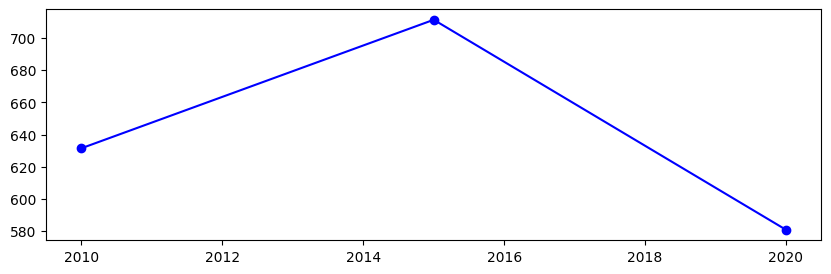

In [39]:
# Filter data for a specific country
afg_data = economies[economies['code'] == 'AFG']

# Line plot of gdp_percapita over the years
plt.figure(figsize=(10, 3));
plt.plot(afg_data['year'], afg_data['gdp_percapita'], 
         marker='o', linestyle='-', color='b');
plt.show();

### Bar chart with Matplotlib

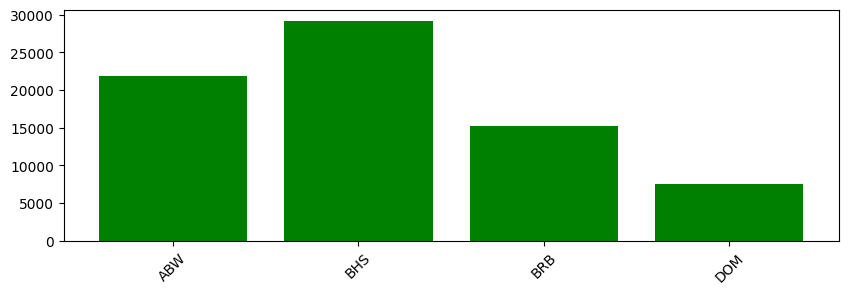

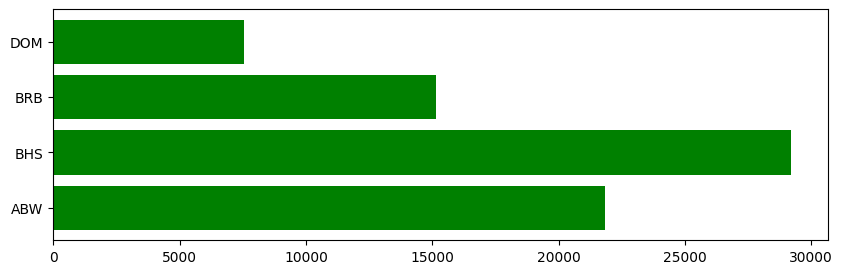

In [40]:
# Filter data for Caribbean countries and the year 2020
caribbean_countries = ['ABW', 'BHS', 'BRB', 'DOM']
data_2020_caribbean = economies[(economies['year'] == 2020) & (economies['code'].isin(caribbean_countries))]

# Bar chart of gdp_percapita for different Caribbean countries in 2020
plt.figure(figsize=(10, 3))
plt.bar(x=data_2020_caribbean['code'], 
        height=data_2020_caribbean['gdp_percapita'], 
        color='g')
plt.xticks(rotation=45);
plt.show();

# Horizontal version
plt.figure(figsize=(10, 3))
plt.barh(y=data_2020_caribbean['code'], 
         width=data_2020_caribbean['gdp_percapita'], 
         color='g')
plt.show();

### Adding labels and titles

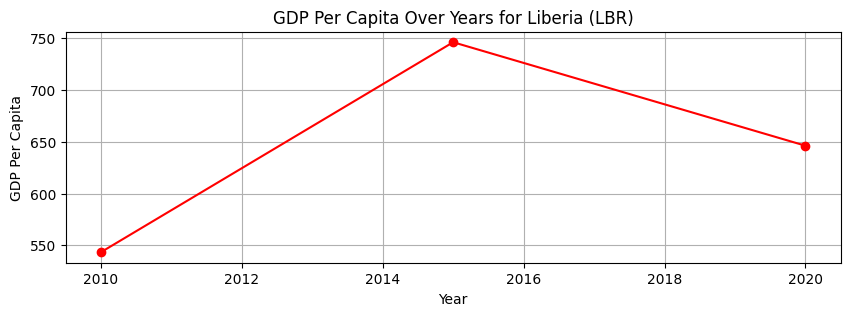

In [41]:
# Filter data for a specific country
liberia_data = economies[economies['code'] == 'LBR']

# Line plot of gdp_percapita over the years with labels and titles
plt.figure(figsize=(10, 3))
plt.plot(liberia_data['year'], liberia_data['gdp_percapita'], marker='o', linestyle='-', color='r');
plt.xlabel('Year');
plt.ylabel('GDP Per Capita');
plt.title('GDP Per Capita Over Years for Liberia (LBR)');
plt.grid(True);
plt.show();

### Adjusting axes and tick marks

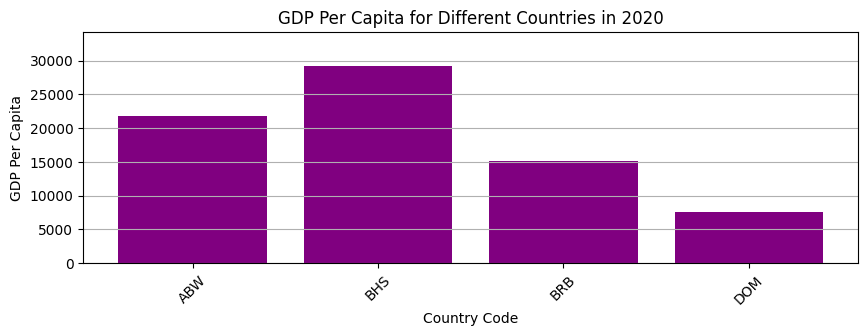

In [42]:
# Bar chart of gdp_percapita for different Caribbean countries in 2020 with 
# adjusted axes and tick marks
plt.figure(figsize=(10, 3))
plt.bar(data_2020_caribbean['code'], data_2020_caribbean['gdp_percapita'], color='purple')
plt.xlabel('Country Code')
plt.ylabel('GDP Per Capita')
plt.title('GDP Per Capita for Different Countries in 2020')

# Adjust axes
plt.ylim(0, max(data_2020_caribbean['gdp_percapita']) + 5000);

# Adjust tick marks
plt.xticks(rotation=45);
plt.yticks(range(0, int(max(data_2020_caribbean['gdp_percapita']) + 5000), 5000));

plt.grid(axis='y')
plt.show();

### Histogram with Seaborn

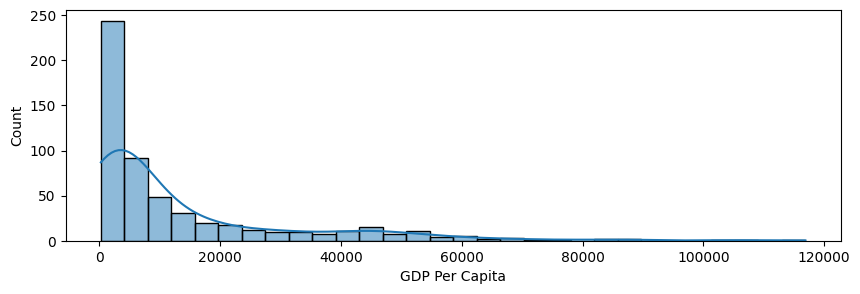

In [43]:
plt.figure(figsize=(10, 3))
sns.histplot(economies['gdp_percapita'], bins=30, kde=True)
plt.xlabel('GDP Per Capita')
plt.show();

### Boxplot with Seaborn

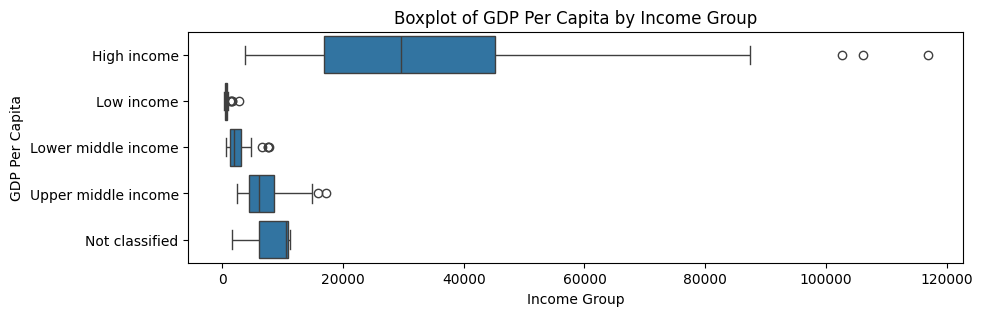

In [44]:
plt.figure(figsize=(10, 3))
sns.boxplot(x='gdp_percapita', y='income_group', data=economies)
plt.xlabel('Income Group')
plt.ylabel('GDP Per Capita')
plt.title('Boxplot of GDP Per Capita by Income Group')
plt.show();

### Violin plot with Seaborn

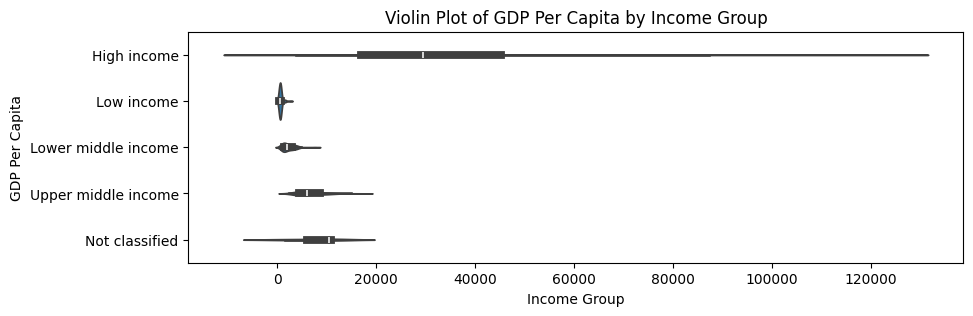

In [45]:
plt.figure(figsize=(10, 3))
sns.violinplot(x='gdp_percapita', y='income_group', data=economies)
plt.xlabel('Income Group')
plt.ylabel('GDP Per Capita')
plt.title('Violin Plot of GDP Per Capita by Income Group')
plt.show();

## Exercise #5: Data Visualization Techniques

### Line Plot with Matplotlib

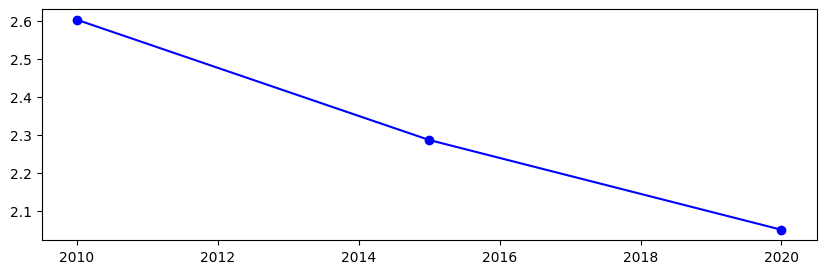

In [46]:
# Filter data for India
india_data = populations[populations['country_code'] == 'IND']

# Line plot of fertility rate over the years
plt.figure(figsize=(10, 3))
plt.plot(india_data['year'], india_data['fertility_rate'], marker='o', linestyle='-', color='b')
plt.show();

### Bar Chart with Matplotlib

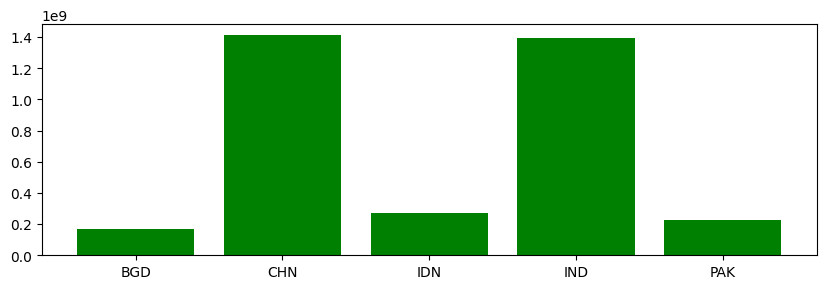

In [47]:
# Filter data for selected Asian countries and the year 2020
asian_countries = ['CHN', 'IND', 'IDN', 'PAK', 'BGD']
data_2020_asia = populations[(populations['year'] == 2020) & (populations['country_code'].isin(asian_countries))]

# Bar chart of population size for selected Asian countries in 2020
plt.figure(figsize=(10, 3))
plt.bar(data_2020_asia['country_code'], data_2020_asia['size'], color='g')
plt.show();

### Adding Labels and Titles

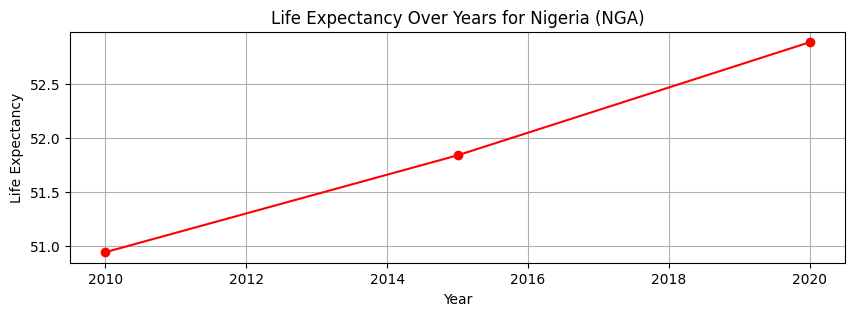

In [48]:
# Filter data for Nigeria
nigeria_data = populations[populations['country_code'] == 'NGA']

# Line plot of life expectancy over the years with labels and titles
plt.figure(figsize=(10, 3))
plt.plot(nigeria_data['year'], nigeria_data['life_expectancy'], 
         marker='o', linestyle='-', color='r')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy Over Years for Nigeria (NGA)')
plt.grid(True)
plt.show();

### Adjusting Axes and Tick Marks

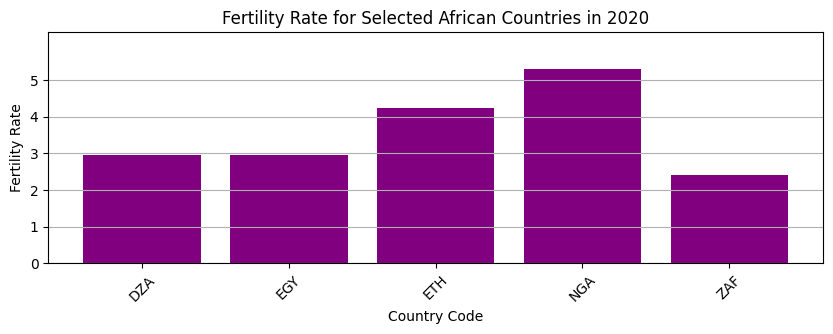

In [49]:
# Filter data for selected African countries ('NGA', 'ETH', 'EGY', 'ZAF', 'DZA')
# and the year 2020
african_countries = ['NGA', 'ETH', 'EGY', 'ZAF', 'DZA']

data_2020_africa = populations[(populations['year'] == 2020) & (populations['country_code'].isin(african_countries))]

# Bar chart of fertility rate for selected African countries in 2020 with 
# adjusted axes and tick marks
plt.figure(figsize=(10, 3))
plt.bar(data_2020_africa['country_code'], data_2020_africa['fertility_rate'], color='purple')
plt.xlabel('Country Code')
plt.ylabel('Fertility Rate')
plt.title('Fertility Rate for Selected African Countries in 2020')

# Adjust axes
plt.ylim(0, max(data_2020_africa['fertility_rate']) + 1);

# Adjust tick marks
plt.xticks(rotation=45);
plt.yticks(range(0, int(max(data_2020_africa['fertility_rate']) + 1), 1));

plt.grid(axis='y');
plt.show();

### Histogram with Seaborn

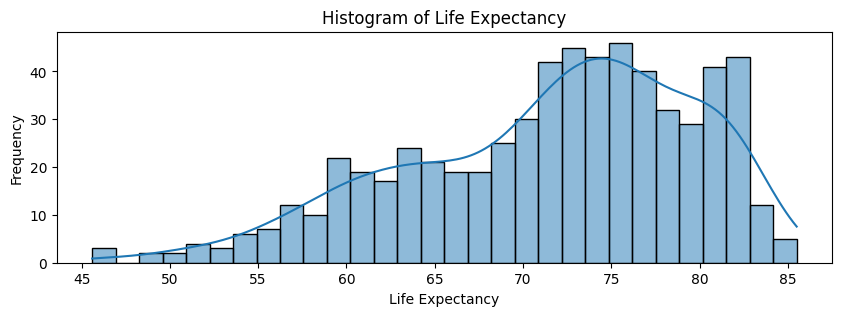

In [50]:
# Histogram of life expectancy
plt.figure(figsize=(10, 3))
sns.histplot(populations['life_expectancy'], bins=30, kde=True)
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.title('Histogram of Life Expectancy')
plt.show();

### Boxplot with Seaborn

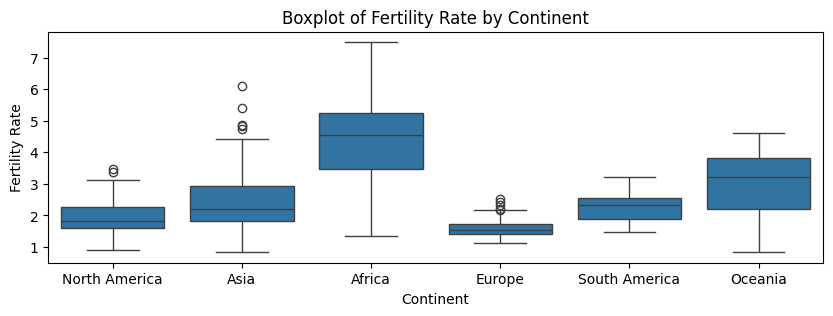

In [51]:
# Boxplot of fertility rate by continent
plt.figure(figsize=(10, 3))
sns.boxplot(x='continent', y='fertility_rate', data=populations)
plt.xlabel('Continent')
plt.ylabel('Fertility Rate')
plt.title('Boxplot of Fertility Rate by Continent')
plt.show();

### Violin Plot with Seaborn

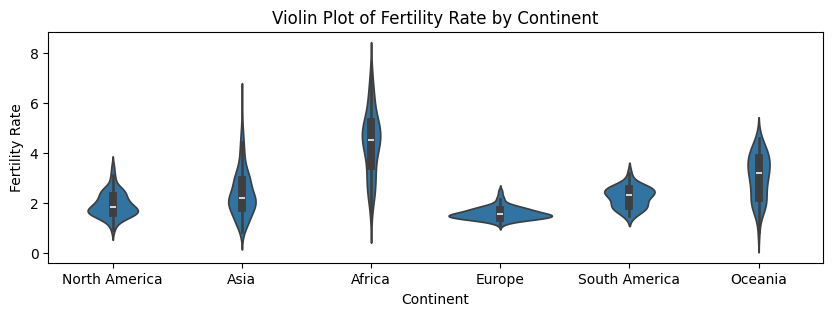

In [52]:
# Violin plot of fertility rate by continent
plt.figure(figsize=(10, 3))
sns.violinplot(x='continent', y='fertility_rate', data=populations)
plt.xlabel('Continent')
plt.ylabel('Fertility Rate')
plt.title('Violin Plot of Fertility Rate by Continent')
plt.show();

------------------------------------------------------------------------

# Module 5: Interactive Data Visualization with Plotly

## Walkthrough #6: Interactive Charts and Dashboards with Plotly

### Basic interactive chart

In [59]:
# Filter data for a specific country
afg_data = economies[economies['code'] == 'AFG']

# Create an interactive line chart
fig = px.line(afg_data, x='year', y='gdp_percapita', 
              title='GDP Per Capita Over Years for Afghanistan (AFG)')
fig.show()

### Adding interactive elements

In [54]:
# Create an interactive scatter plot
fig = px.scatter(economies, x='gdp_percapita', y='gross_savings', color='income_group',
                 hover_name='code', title='GDP Per Capita vs. Gross Savings',
                 labels={'gdp_percapita': 'GDP Per Capita', 'gross_savings': 'Gross Savings (%)'})

# Add hover, zoom, and selection tools
fig.update_traces(marker=dict(size=10), selector=dict(mode='markers'));
fig.update_layout(hovermode='closest');

fig.show()

### Designing a simple dashboard

In [55]:
# Filter data for the year 2020
data_2020 = economies[economies['year'] == 2020]

# Create a subplot figure with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('GDP Per Capita Over Years for Afghanistan', 
                                    'GDP Per Capita for Different Countries in 2020'))

# Line chart of GDP Per Capita for Afghanistan
afg_data = economies[economies['code'] == 'AFG']
line_chart = go.Scatter(x=afg_data['year'], y=afg_data['gdp_percapita'], 
                        mode='lines+markers', name='Afghanistan');
fig.add_trace(line_chart, row=1, col=1);

# Bar chart of GDP Per Capita for different countries in 2020
bar_chart = go.Bar(x=data_2020['code'], y=data_2020['gdp_percapita'], name='2020')
fig.add_trace(bar_chart, row=1, col=2);

# Update layout
fig.update_layout(title_text='Simple Dashboard with Multiple Charts',
                  showlegend=False, width=830, height=500);

fig.show()

## Exercise #6: Interactive Charts and Dashboards with Plotly

### Basic Interactive Chart

In [56]:
# Filter data for a specific country (Brazil)
bra_data = populations[populations['country_code'] == 'BRA']

# Create an interactive line chart (Fertility Rate Over Years)
fig = px.line(bra_data, x='year', y='fertility_rate', 
              title='Fertility Rate Over Years for Brazil (BRA)')
fig.show()

### Adding Interactive Elements

In [57]:
# Create an interactive scatter plot
fig = px.scatter(
  populations, 
  x='fertility_rate', y='life_expectancy', color='continent',
  hover_name='country', title='Fertility Rate vs. Life Expectancy',
  labels={'fertility_rate': 'Fertility Rate', 'life_expectancy': 'Life Expectancy'}
)

# Add hover, zoom, and selection tools
fig.update_traces(marker=dict(size=10), selector=dict(mode='markers'));
fig.update_layout(hovermode='closest');

fig.show()

### Designing a Simple Dashboard

In [58]:
# Filter data for the year 2020
data_2020 = populations[populations['year'] == 2020]

# Create a subplot figure with 1 row and 2 columns
fig = make_subplots(
  rows=1, cols=2, 
  subplot_titles=('Life Expectancy Over Years for Brazil', 
                  'Life Expectancy for Different Countries in 2020'));

# Line chart of Life Expectancy for Brazil
bra_data = populations[populations['country_code'] == 'BRA']
line_chart = go.Scatter(x=bra_data['year'], y=bra_data['life_expectancy'], 
                        mode='lines+markers', name='Brazil')
fig.add_trace(line_chart, row=1, col=1);

# Bar chart of Life Expectancy for South American countries in 2020
south_american_data_2020 = data_2020[data_2020['continent'] == 'South America']
bar_chart = go.Bar(x=south_american_data_2020['country'], 
                   y=south_american_data_2020['life_expectancy'], name='2020')
fig.add_trace(bar_chart, row=1, col=2);

# Update layout to add a title and hide the legend
fig.update_layout(title_text='Simple Dashboard with Multiple Charts', 
                  showlegend=False);
fig.show()